# Taller: Deep Learning con Series de Tiempo (EEG Motor Imagery) - LSTM

## 1. Introducción

Motor imagery (imaginación motora) es una técnica ampliamente utilizada en neuroingeniería y en interfaces cerebro–computador (BCI). Consiste en imaginar la ejecución de un movimiento sin realizarlo físicamente, lo que activa patrones eléctricos cerebrales similares a los generados durante el movimiento real.

Durante la imaginación de mover una mano, por ejemplo, se produce una modulación característica en las áreas motoras del cerebro (principalmente en la corteza motora contralateral), observable en el EEG como cambios en los ritmos mu (8–13 Hz) y beta (13–30 Hz). Estas variaciones se conocen como event-related desynchronization/synchronization (ERD/ERS).

El objetivo en los experimentos de MI es distinguir automáticamente entre distintas clases mentales (por ejemplo, imaginar mover la mano izquierda vs. la derecha) a partir de estas señales EEG. Para ello, se aplican modelos de aprendizaje automático y, más recientemente, redes neuronales profundas que pueden aprender directamente patrones espacio–temporales.

En este taller trabajaremos con un subconjunto de datos de EEG registrados en los electrodos C3, Cz y C4, situados sobre el área motora, para entrenar un modelo LSTM (Long Short-Term Memory) capaz de identificar el tipo de imaginación motora representada en cada ensayo

## 2. Objetivos
Objetivo general aplicar un flujo completo de DL sobre series de tiempo:
1. Visualización de señales
2. Verificación de balance
3. Creación de Dataset
4. Entrenamiento de un LSTM
5. Análisis de sobreajuste variando hiperparámetros.


## 3. Dataset


El conjunto de datos [BCI Competition IV](https://www.bbci.de/competition/iv/) – Dataset 2b fue desarrollado por el Laboratory of Brain-Computer Interfaces en Graz University of Technology (Austria). Este dataset fue diseñado para evaluar algoritmos de clasificación de motor imagery (MI) en condiciones realistas y mínimamente instrumentadas, simulando un sistema BCI práctico. Contiene registros de EEG cued motor imagery, es decir, tareas de imaginación motora guiadas por una señal visual en las que los participantes imaginaban mover su mano izquierda o derecha siguiendo las instrucciones presentadas en pantalla.

Las características principales del conjunto son:

* Sujetos: 9 voluntarios sanos.
* Canales EEG: 3 bipolares (C3, Cz y C4) ubicados sobre la corteza motora.
* Canales EOG: 3 adicionales para registrar artefactos oculares.
* Frecuencia de muestreo: 250 Hz.
* Filtros aplicados: 0.5–100 Hz (con notch a 50 Hz).
* Clases: dos categorías (imaginación de movimiento de la mano izquierda (0) y mano derecha (1)).

Para este taller, se entregará una matriz `X` con las señales EEG preprocesadas y una matriz `Y` con las etiquetas correspondientes (0 o 1). Cada muestra de `X` representa un ensayo individual de imaginación motora, correspondiente a un intervalo de 1 segundo de señal EEG. En este intervalo, el sujeto se encontraba realizando la tarea de imaginar el movimiento indicado (izquierda o derecha).

Por lo tanto:

* `X` tiene forma `(N, C, T)`, donde

  * `N` es el número total de ensayos,
  * `C` corresponde a los tres canales EEG (C3, Cz, C4), y
  * `T` es el número de puntos temporales en cada ensayo (750 muestras en 3 segundos). 
* `Y` contiene las etiquetas binarias asociadas a cada ensayo (`0` = mano izquierda, `1` = mano derecha).

A partir de estos datos, podremos visualizar las señales crudas, verificar el balance de clases, entrenar modelos de deep learning y evaluar su desempeño.


<div style="text-align:center;">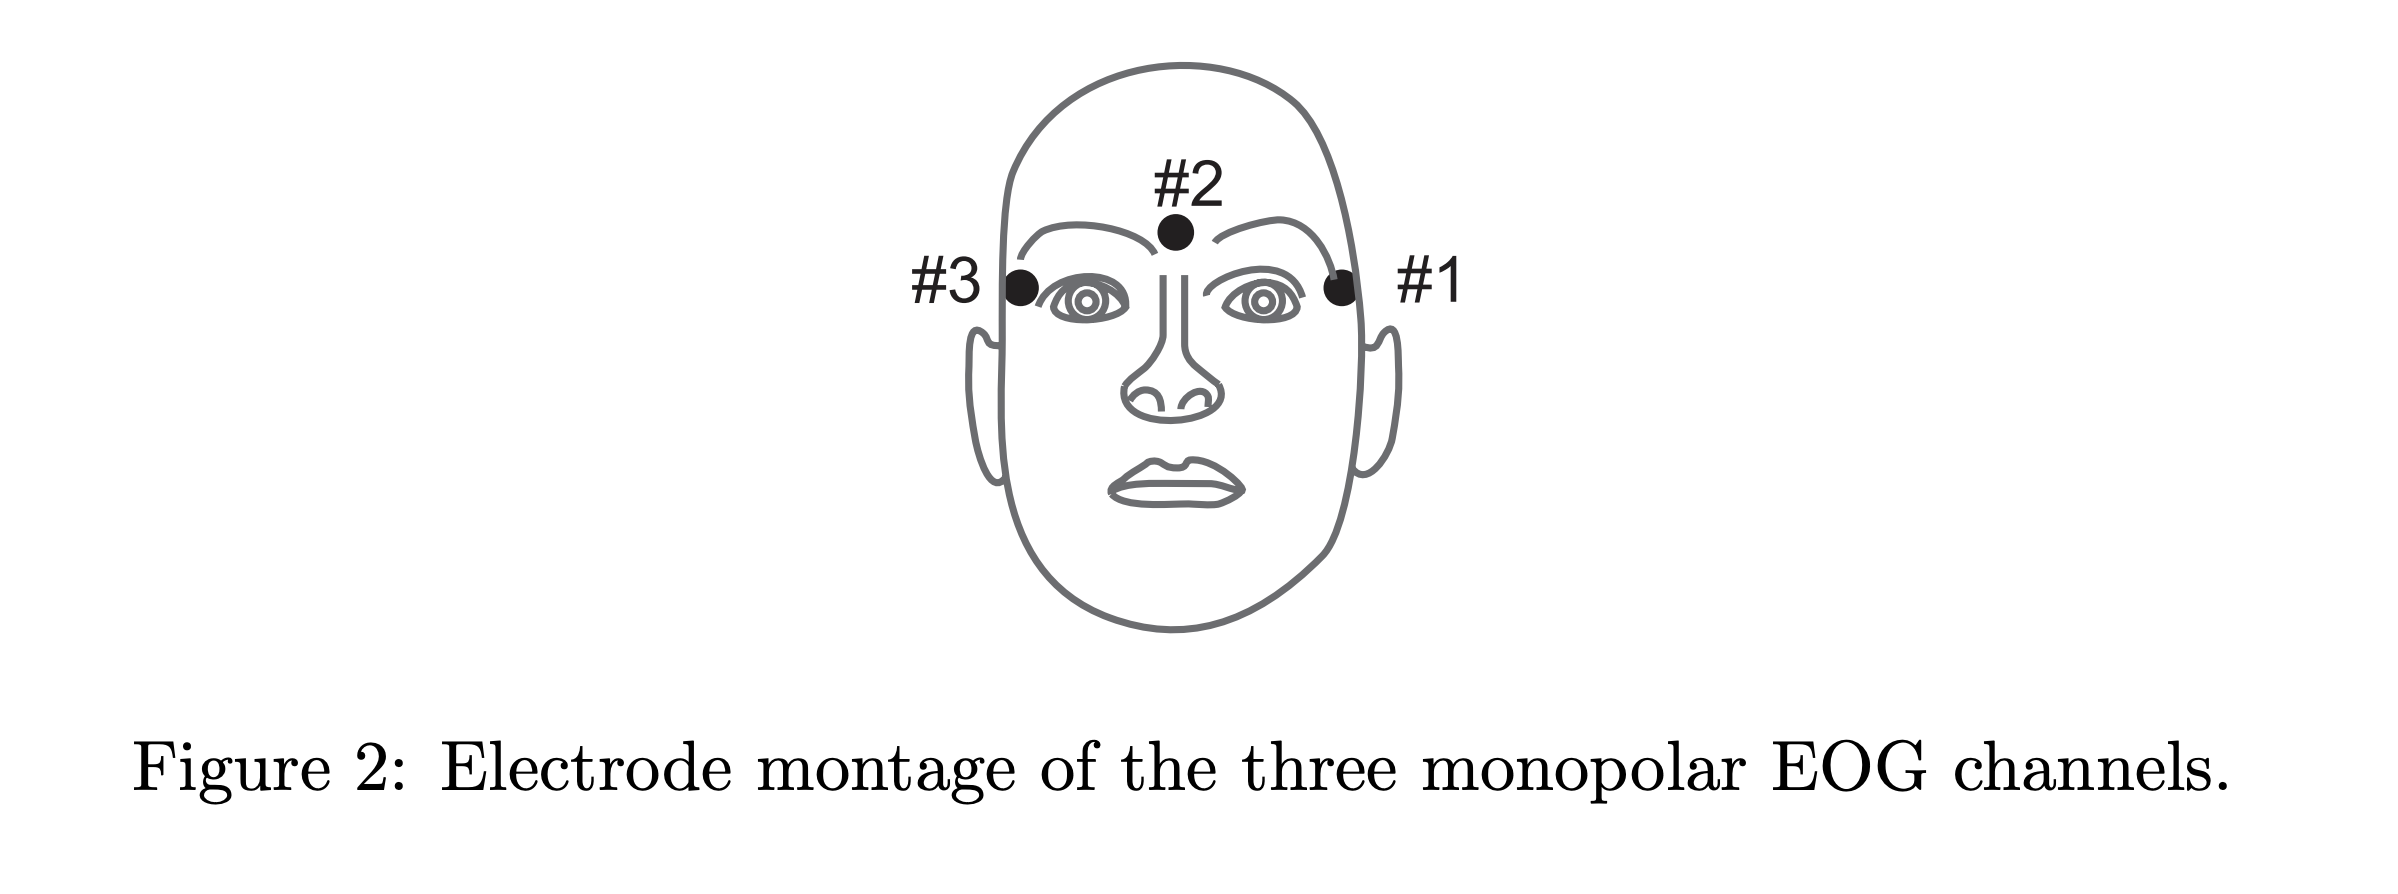</div>




### 3.1 Descargar y descomprimir el conjunto de datos BCICIV_2b_gdf

In [ ]:
!wget -q https://www.bbci.de/competition/download/competition_iv/BCICIV_2b_gdf.zip
!unzip -q BCICIV_2b_gdf.zip

### 3.2 Cargar el conjunto de datos BCICIV_2b_gdf

In [ ]:
import mne  # Librería para manejo de EEG
import numpy as np
import os

X, Y = [], []
archivos = [f for f in os.listdir() if f.endswith(".gdf")]

for archivo in archivos:
    raw = mne.io.read_raw_gdf(archivo, verbose=False, include=['EEG:C3','EEG:C4','EEG:Cz'])
    sf = raw.info['sfreq']
    for annot in raw.annotations:
        if annot['description'] in ['769','770']:
            onset = int(annot['onset'] * sf)
            seg = raw.get_data(start=onset, stop=onset + int(1*sf), units='uV')  # (C,T)
            X.append(seg)
            Y.append(0 if annot['description']=='769' else 1)

X = np.array(X)  # (N,C,T)
Y = np.array(Y)  # (N,)
# Normalización global (z-score)
X = (X - X.mean()) / (X.std() + 1e-8)
print("Shapes:", X.shape, Y.shape, "Mean:", X.mean().round(4), "Std:", X.std().round(4))



## 4. Entrenamiento
#### **Ejercicio 1** 
- Grafica 3 ensayos (trials) de la **clase 0** y 3 de la **clase 1** (los tres canales).
- Haz un `subplot` por canal (C3, Cz, C4). Añade leyenda y títulos.


In [ ]:
# <CODE>


#### **Ejercicio 2** 
En el siguiente ejercicio debes verificar si el conjunto de datos está balanceado en cuanto a las clases.
- Cuenta instancias por clase y grafícalas en un bar plot.
- Comenta si hay desbalance o no. Comenta sobre el diseño experimental del conjunto de datos.

In [ ]:

# <CODE>



#### **Ejercicio 3** 


Antes de entrenar un modelo en PyTorch, es fundamental preparar adecuadamente los datos. Cuando el conjunto de datos no se encuentra en un formato estándar, es habitual definir una clase personalizada que herede de `torch.utils.data.Dataset`. Esta clase debe implementar los métodos `__len__` y `__getitem__`, que permiten acceder de forma estructurada a las muestras y etiquetas.

En este ejercicio, deberás crear una clase personalizada para el conjunto de datos **BCICIV_2b_gdf** y preparar los datos para su uso en entrenamiento:

* Define una clase `BCIDataset` que herede de `torch.utils.data.Dataset`.
* Implementa el método `__len__` para devolver el número total de muestras.
* Implementa el método `__getitem__` para retornar un par `(x, y)` como tensores.
* Realiza una división **estratificada** en conjuntos de **entrenamiento (80%)** y **prueba (20%)**.
* Crea los correspondientes `DataLoader` con `batch_size=32`, usando `shuffle=True` únicamente para el conjunto de entrenamiento.


HINT: 
```python
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class BCIDataset(Dataset):
    def __init__(self, X, y):
        ...

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# División estratificada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Creación de datasets y dataloaders
train_dataset = BCIDataset(X_train, y_train)
test_dataset  = BCIDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)
```




In [ ]:
# <CODE>


#### **Ejercicio 4** 
- Implementa un modelo LSTM que reciba secuencias `(B, T, C)` y devuelva logits `(B,1)`.
    * Usa 2 capas LSTM con `hidden_size=64` y `num_layers=2`.
    * Añade una capa fully connected al final.
- Entrénalo **50 épocas** con `Adam(lr=1e-3)` y `BCEWithLogitsLoss`.
- Registra `loss` y `accuracy` en train/test y grafícalos.



In [ ]:

# <CODE>


#### **Ejercicio 5** 


Para analizar cómo los hiperparámetros afectan el rendimiento del modelo, modifica las configuraciones indicadas a continuación y observa sus efectos en las curvas de **entrenamiento** y **validación**:

* Prueba los siguientes valores (de forma individual) y comenta los cambios observados en las curvas:

  * `hidden_size`: 16, 32, 64, 128
  * `num_layers`: 1, 2





In [ ]:

# <CODE> Plantilla rápida para reintentos
